# UTA vs Zhang: comparison notebook

This notebook compares the UTA and Zhang result CSVs on the overlapping experimental support.

Main comparison principle:
- keep only clean Zhang runs (`fit_ok = True`, empty `error`)
- restrict both families to the common structural variables: `noise`, `m`, `L`, `k_non_mono`, `peak_type`
- use direct comparisons only when the interpretation is defensible

Important caveat:
- `UTA` was run with `n_alt = 1000` and budget `n_pairs_train`
- `Zhang` was run with `n_alt = 200` and budget `ref_ratio`
- raw accuracy is informative, but not a perfectly apples-to-apples benchmark

What is most meaningful here:
- global method overview
- best attainable accuracy by family under matched structural conditions
- head-to-head Zhang minus UTA deltas
- robustness to noise relative to each method's own clean baseline
- performance vs compute operating points


In [17]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 11

METHOD_PALETTE = {
    "UTA A (mono)": "#4C78A8",
    "UTA B (non-mono)": "#72B7B2",
    "Zhang A1": "#E45756",
    "Zhang A2": "#F58518",
}

FAMILY_PALETTE = {
    "UTA": "#4C78A8",
    "Zhang": "#E45756",
}

METHOD_ORDER = ["UTA A (mono)", "UTA B (non-mono)", "Zhang A1", "Zhang A2"]
FAMILY_ORDER = ["UTA", "Zhang"]


In [18]:
PROJECT_DIR = Path.cwd()
UTA_CSV = PROJECT_DIR / "uta_experiment__results.csv"
ZHANG_CSV = PROJECT_DIR / "zhang_experiment_results.csv"

ONLY_COMMON_SUPPORT = True
ZHANG_CLEAN_ONLY = True
SAVE_FIGURES = False
FIG_DIR = PROJECT_DIR / "UTA" / "figures_uta_vs_zhang"

if SAVE_FIGURES:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

display(Markdown(f"**UTA CSV**: `{UTA_CSV.name}`  \\n**Zhang CSV**: `{ZHANG_CSV.name}`"))


**UTA CSV**: `uta_experiment__results.csv`  \n**Zhang CSV**: `zhang_experiment_results.csv`

In [19]:
uta = pd.read_csv(UTA_CSV, sep=";")
zh = pd.read_csv(ZHANG_CSV, low_memory=False)

zh["error"] = zh["error"].fillna("").astype(str).str.strip()
zh["fit_ok_bool"] = zh["fit_ok"].astype(str).str.lower().isin({"true", "1", "1.0"})

if ZHANG_CLEAN_ONLY:
    zh = zh[(zh["fit_ok_bool"]) & (zh["error"] == "")].copy()

common_support = {}
for col in ["noise", "m", "L", "k_non_mono", "peak_type"]:
    common_support[col] = sorted(set(uta[col].dropna().unique()) & set(zh[col].dropna().unique()))

if ONLY_COMMON_SUPPORT:
    for col, values in common_support.items():
        uta = uta[uta[col].isin(values)].copy()
        zh = zh[zh[col].isin(values)].copy()

uta["family"] = "UTA"
zh["family"] = "Zhang"

uta["method_label"] = uta["method"].map({"A_mono": "UTA A (mono)", "B_nonmono": "UTA B (non-mono)"})
zh["method_label"] = zh["method"].map({"zhang_A1": "Zhang A1", "zhang_A2": "Zhang A2"})

uta["budget_value"] = uta["n_pairs_train"].astype(float)
uta["budget_label"] = uta["n_pairs_train"].astype(int).astype(str) + " pairs"

zh["budget_value"] = zh["ref_ratio"].astype(float)
zh["budget_label"] = "ref=" + zh["ref_ratio"].map(lambda x: f"{x:.1f}")

summary = pd.DataFrame(
    [
        {
            "family": "UTA",
            "rows": len(uta),
            "methods": uta["method_label"].nunique(),
            "n_alt values": ", ".join(map(str, sorted(uta["n_alt"].dropna().unique()))),
            "budget axis": "n_pairs_train",
        },
        {
            "family": "Zhang",
            "rows": len(zh),
            "methods": zh["method_label"].nunique(),
            "n_alt values": ", ".join(map(str, sorted(zh["n_alt"].dropna().unique()))),
            "budget axis": "ref_ratio",
        },
    ]
)

support_table = pd.DataFrame({k: [", ".join(map(str, v))] for k, v in common_support.items()})

display(Markdown("### Loaded data summary"))
display(summary)
display(Markdown("### Common support used for the comparison"))
display(support_table)

combined = pd.concat(
    [
        uta[["family", "method_label", "acc_test", "cpu_sec"]],
        zh[["family", "method_label", "acc_test", "cpu_sec"]],
    ],
    ignore_index=True,
)

display(Markdown(
    "**Interpretation note**: the notebook keeps the comparisons honest, but raw accuracy still mixes different `n_alt` values and different budget definitions. Use the family-best, delta, and robustness views as the main decision tools."
))


### Loaded data summary

,family,rows,methods,n_alt values,budget axis
0,UTA,69120,2,1000,n_pairs_train
1,Zhang,38897,2,200,ref_ratio


### Common support used for the comparison

,noise,m,L,k_non_mono,peak_type
0,"0.0, 0.05, 0.1","3, 4, 6, 8","4, 5, 6","0, 1, 2, 3","central, extreme"


**Interpretation note**: the notebook keeps the comparisons honest, but raw accuracy still mixes different `n_alt` values and different budget definitions. Use the family-best, delta, and robustness views as the main decision tools.

In [20]:
def maybe_savefig(name: str):
    if SAVE_FIGURES:
        plt.savefig(FIG_DIR / name, dpi=200, bbox_inches="tight")


def annotate_bars(ax, fmt="{:.3f}", percent=False):
    for patch in ax.patches:
        value = patch.get_height()
        if np.isnan(value):
            continue
        label = f"{value:.0%}" if percent else fmt.format(value)
        ax.annotate(
            label,
            (patch.get_x() + patch.get_width() / 2, value),
            ha="center",
            va="bottom",
            fontsize=10,
            xytext=(0, 5),
            textcoords="offset points",
        )


GROUP_COLS = ["noise", "m", "L", "k_non_mono", "peak_type"]

uta_best = uta.groupby(GROUP_COLS)["acc_test"].max().rename("uta_best_acc")
zh_best = zh.groupby(GROUP_COLS)["acc_test"].max().rename("zhang_best_acc")
head_to_head = pd.concat([uta_best, zh_best], axis=1).dropna().reset_index()
head_to_head["delta_zhang_minus_uta"] = head_to_head["zhang_best_acc"] - head_to_head["uta_best_acc"]
head_to_head["winner"] = np.where(head_to_head["delta_zhang_minus_uta"] > 0, "Zhang", "UTA")

method_overview = (
    combined.groupby(["family", "method_label"])
    .agg(
        mean_acc_test=("acc_test", "mean"),
        mean_cpu_sec=("cpu_sec", "mean"),
        n_rows=("acc_test", "size"),
    )
    .reset_index()
)

win_summary = (
    head_to_head.assign(zhang_win=head_to_head["delta_zhang_minus_uta"] > 0)
    .groupby("noise")["zhang_win"]
    .mean()
    .reset_index()
)

display(Markdown("### Method overview table"))
display(method_overview.sort_values("mean_acc_test", ascending=False))

display(Markdown("### Head-to-head summary on matched structural conditions"))
display(head_to_head[["delta_zhang_minus_uta"]].describe().T)
display(win_summary)


### Method overview table

,family,method_label,mean_acc_test,mean_cpu_sec,n_rows
2,Zhang,Zhang A1,0.861587,0.083600,19436
1,UTA,UTA B (non-mono),0.850272,0.111999,34560
0,UTA,UTA A (mono),0.833848,0.115342,34560
3,Zhang,Zhang A2,0.827810,0.081306,19461


### Head-to-head summary on matched structural conditions

,count,mean,std,min,25%,50%,75%,max
delta_zhang_minus_uta,203.0,0.02324,0.020633,-0.043,0.0105,0.027,0.03725,0.0695


,noise,zhang_win
0,0.00,1.000000
1,0.05,0.718750
2,0.10,0.909091


C:\Users\mathy\AppData\Local\Temp\ipykernel_17872\93335240.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\mathy\AppData\Local\Temp\ipykernel_17872\93335240.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


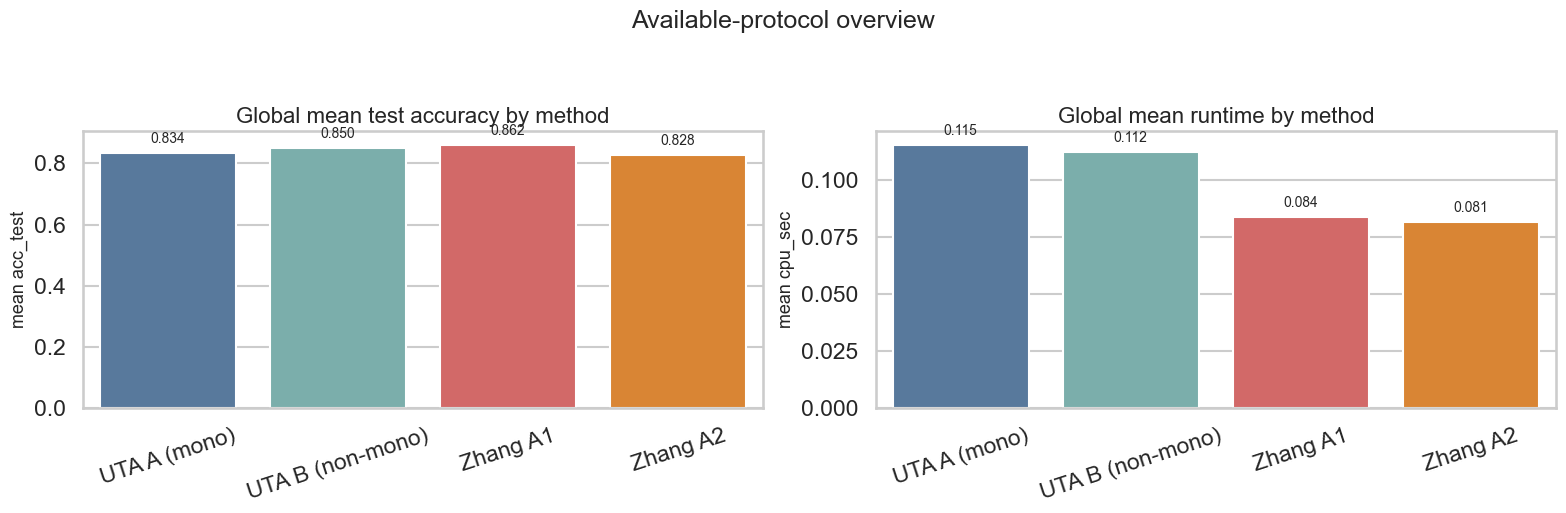

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    data=method_overview,
    x="method_label",
    y="mean_acc_test",
    order=METHOD_ORDER,
    palette=METHOD_PALETTE,
    ax=axes[0],
)
axes[0].set_title("Global mean test accuracy by method")
axes[0].set_xlabel("")
axes[0].set_ylabel("mean acc_test")
axes[0].tick_params(axis="x", rotation=18)
annotate_bars(axes[0])

sns.barplot(
    data=method_overview,
    x="method_label",
    y="mean_cpu_sec",
    order=METHOD_ORDER,
    palette=METHOD_PALETTE,
    ax=axes[1],
)
axes[1].set_title("Global mean runtime by method")
axes[1].set_xlabel("")
axes[1].set_ylabel("mean cpu_sec")
axes[1].tick_params(axis="x", rotation=18)
annotate_bars(axes[1])

plt.suptitle("Available-protocol overview", y=1.04, fontsize=18)
plt.tight_layout()
maybe_savefig("01_method_overview.png")
plt.show()


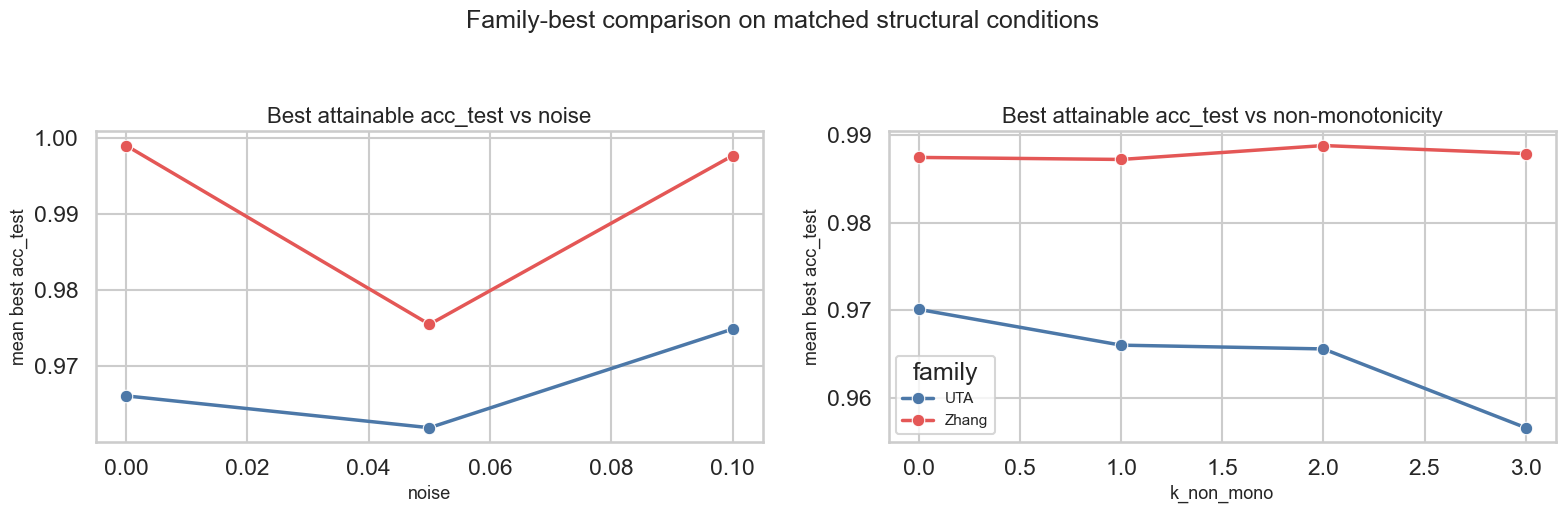

In [22]:
family_noise = (
    head_to_head.groupby("noise")[["uta_best_acc", "zhang_best_acc"]]
    .mean()
    .reset_index()
    .melt(id_vars="noise", var_name="family", value_name="best_acc")
)
family_noise["family"] = family_noise["family"].map({"uta_best_acc": "UTA", "zhang_best_acc": "Zhang"})

family_k = (
    head_to_head.groupby("k_non_mono")[["uta_best_acc", "zhang_best_acc"]]
    .mean()
    .reset_index()
    .melt(id_vars="k_non_mono", var_name="family", value_name="best_acc")
)
family_k["family"] = family_k["family"].map({"uta_best_acc": "UTA", "zhang_best_acc": "Zhang"})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(
    data=family_noise,
    x="noise",
    y="best_acc",
    hue="family",
    hue_order=FAMILY_ORDER,
    palette=FAMILY_PALETTE,
    marker="o",
    linewidth=2.5,
    ax=axes[0],
)
axes[0].set_title("Best attainable acc_test vs noise")
axes[0].set_ylabel("mean best acc_test")
axes[0].set_xlabel("noise")

sns.lineplot(
    data=family_k,
    x="k_non_mono",
    y="best_acc",
    hue="family",
    hue_order=FAMILY_ORDER,
    palette=FAMILY_PALETTE,
    marker="o",
    linewidth=2.5,
    ax=axes[1],
)
axes[1].set_title("Best attainable acc_test vs non-monotonicity")
axes[1].set_ylabel("mean best acc_test")
axes[1].set_xlabel("k_non_mono")

handles, labels = axes[1].get_legend_handles_labels()
axes[0].legend().remove()
axes[1].legend(handles=handles, labels=labels, title="family")

plt.suptitle("Family-best comparison on matched structural conditions", y=1.04, fontsize=18)
plt.tight_layout()
maybe_savefig("02_family_best.png")
plt.show()


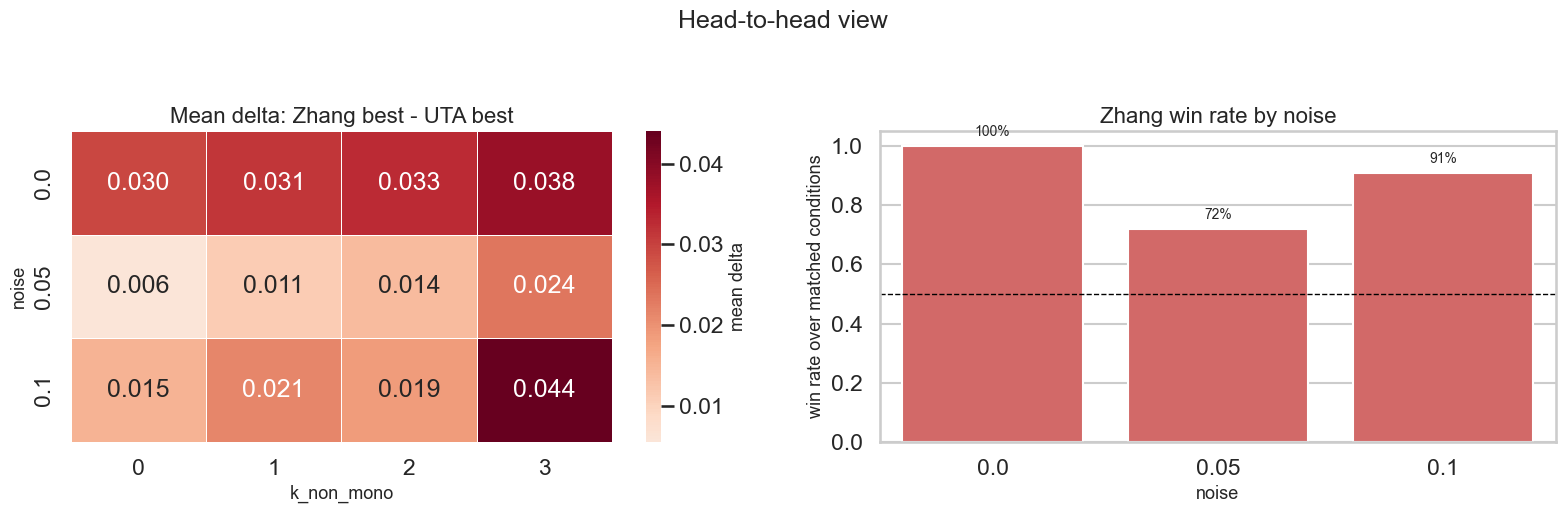

In [23]:
delta_heatmap = head_to_head.pivot_table(
    index="noise",
    columns="k_non_mono",
    values="delta_zhang_minus_uta",
    aggfunc="mean",
)

zhang_win_by_noise = (
    head_to_head.assign(zhang_win=head_to_head["delta_zhang_minus_uta"] > 0)
    .groupby("noise")["zhang_win"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(
    delta_heatmap,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "mean delta"},
    ax=axes[0],
)
axes[0].set_title("Mean delta: Zhang best - UTA best")
axes[0].set_xlabel("k_non_mono")
axes[0].set_ylabel("noise")

sns.barplot(
    data=zhang_win_by_noise,
    x="noise",
    y="zhang_win",
    color=FAMILY_PALETTE["Zhang"],
    ax=axes[1],
)
axes[1].axhline(0.5, color="black", linestyle="--", linewidth=1)
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Zhang win rate by noise")
axes[1].set_xlabel("noise")
axes[1].set_ylabel("win rate over matched conditions")
annotate_bars(axes[1], percent=True)

plt.suptitle("Head-to-head view", y=1.04, fontsize=18)
plt.tight_layout()
maybe_savefig("03_head_to_head.png")
plt.show()


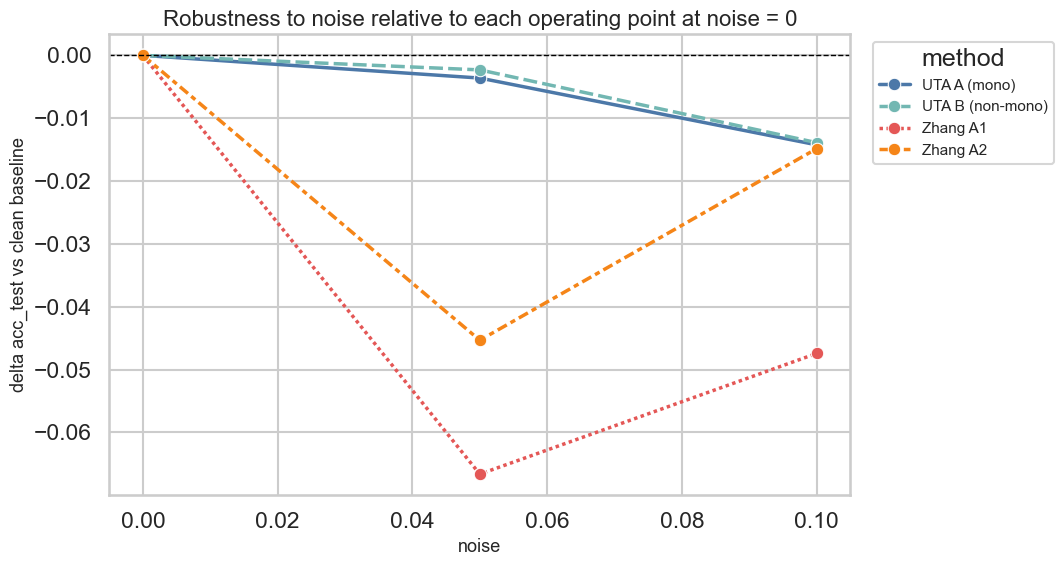

In [24]:
uta_drop = uta.groupby(["method_label", "budget_label", "noise"])["acc_test"].mean().reset_index()
uta_base = uta_drop[uta_drop["noise"] == 0.0][["method_label", "budget_label", "acc_test"]].rename(columns={"acc_test": "base_acc"})
uta_drop = uta_drop.merge(uta_base, on=["method_label", "budget_label"], how="inner")
uta_drop["delta_from_clean"] = uta_drop["acc_test"] - uta_drop["base_acc"]

zh_drop = zh.groupby(["method_label", "budget_label", "noise"])["acc_test"].mean().reset_index()
zh_base = zh_drop[zh_drop["noise"] == 0.0][["method_label", "budget_label", "acc_test"]].rename(columns={"acc_test": "base_acc"})
zh_drop = zh_drop.merge(zh_base, on=["method_label", "budget_label"], how="inner")
zh_drop["delta_from_clean"] = zh_drop["acc_test"] - zh_drop["base_acc"]

drop_summary = pd.concat([uta_drop, zh_drop], ignore_index=True)
drop_summary = drop_summary.groupby(["method_label", "noise"])["delta_from_clean"].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 6))
sns.lineplot(
    data=drop_summary,
    x="noise",
    y="delta_from_clean",
    hue="method_label",
    style="method_label",
    hue_order=METHOD_ORDER,
    style_order=METHOD_ORDER,
    palette=METHOD_PALETTE,
    marker="o",
    linewidth=2.5,
    ax=ax,
)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Robustness to noise relative to each operating point at noise = 0")
ax.set_xlabel("noise")
ax.set_ylabel("delta acc_test vs clean baseline")
ax.legend(title="method", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
maybe_savefig("04_noise_robustness.png")
plt.show()


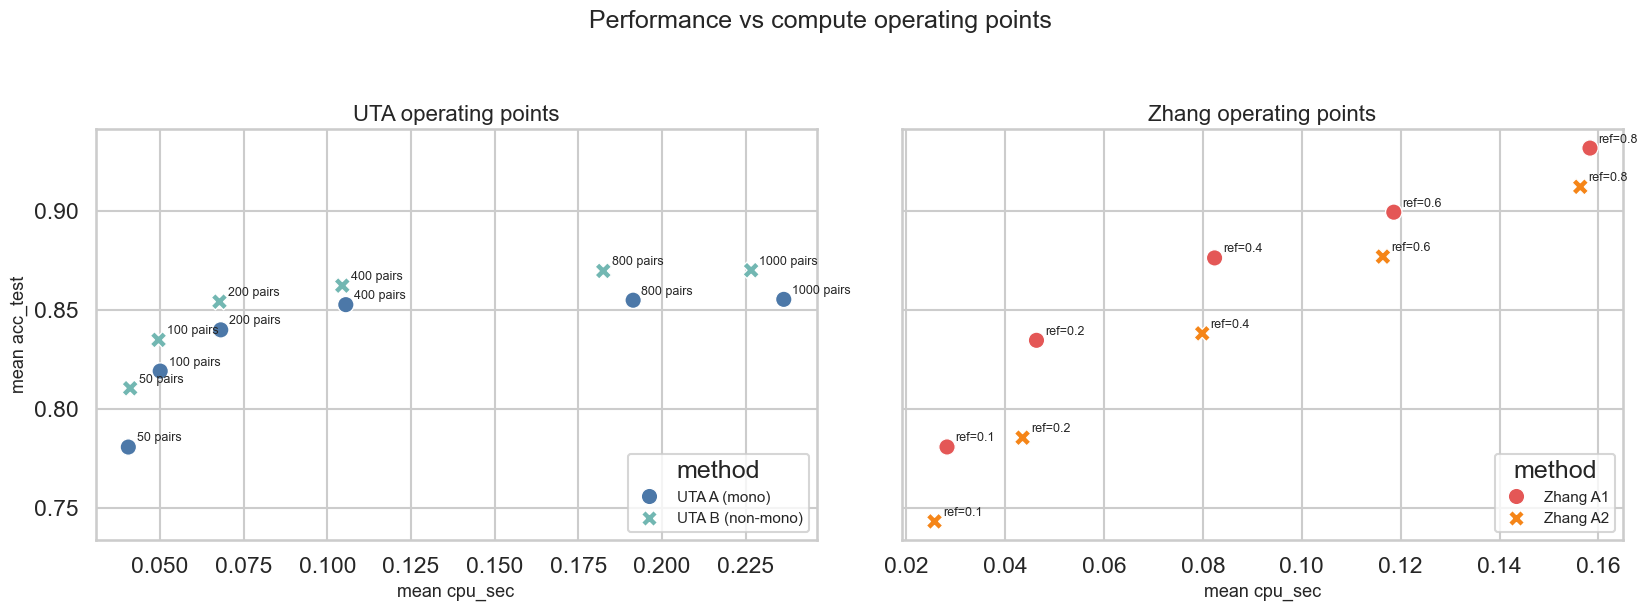

In [25]:
uta_ops = (
    uta.groupby(["method_label", "n_pairs_train"])
    .agg(acc_test=("acc_test", "mean"), cpu_sec=("cpu_sec", "mean"))
    .reset_index()
)
uta_ops["setting"] = uta_ops["n_pairs_train"].astype(int).astype(str) + " pairs"

zh_ops = (
    zh.groupby(["method_label", "ref_ratio"])
    .agg(acc_test=("acc_test", "mean"), cpu_sec=("cpu_sec", "mean"))
    .reset_index()
)
zh_ops["setting"] = "ref=" + zh_ops["ref_ratio"].map(lambda x: f"{x:.1f}")

fig, axes = plt.subplots(1, 2, figsize=(17, 6), sharey=True)

sns.scatterplot(
    data=uta_ops,
    x="cpu_sec",
    y="acc_test",
    hue="method_label",
    style="method_label",
    palette=METHOD_PALETTE,
    s=140,
    ax=axes[0],
)
axes[0].set_title("UTA operating points")
axes[0].set_xlabel("mean cpu_sec")
axes[0].set_ylabel("mean acc_test")
for _, row in uta_ops.iterrows():
    axes[0].annotate(row["setting"], (row["cpu_sec"], row["acc_test"]), textcoords="offset points", xytext=(6, 4), fontsize=9)

sns.scatterplot(
    data=zh_ops,
    x="cpu_sec",
    y="acc_test",
    hue="method_label",
    style="method_label",
    palette=METHOD_PALETTE,
    s=140,
    ax=axes[1],
)
axes[1].set_title("Zhang operating points")
axes[1].set_xlabel("mean cpu_sec")
axes[1].set_ylabel("")
for _, row in zh_ops.iterrows():
    axes[1].annotate(row["setting"], (row["cpu_sec"], row["acc_test"]), textcoords="offset points", xytext=(6, 4), fontsize=9)

axes[0].legend(title="method", loc="lower right")
axes[1].legend(title="method", loc="lower right")

plt.suptitle("Performance vs compute operating points", y=1.03, fontsize=18)
plt.tight_layout()
maybe_savefig("05_operating_points.png")
plt.show()


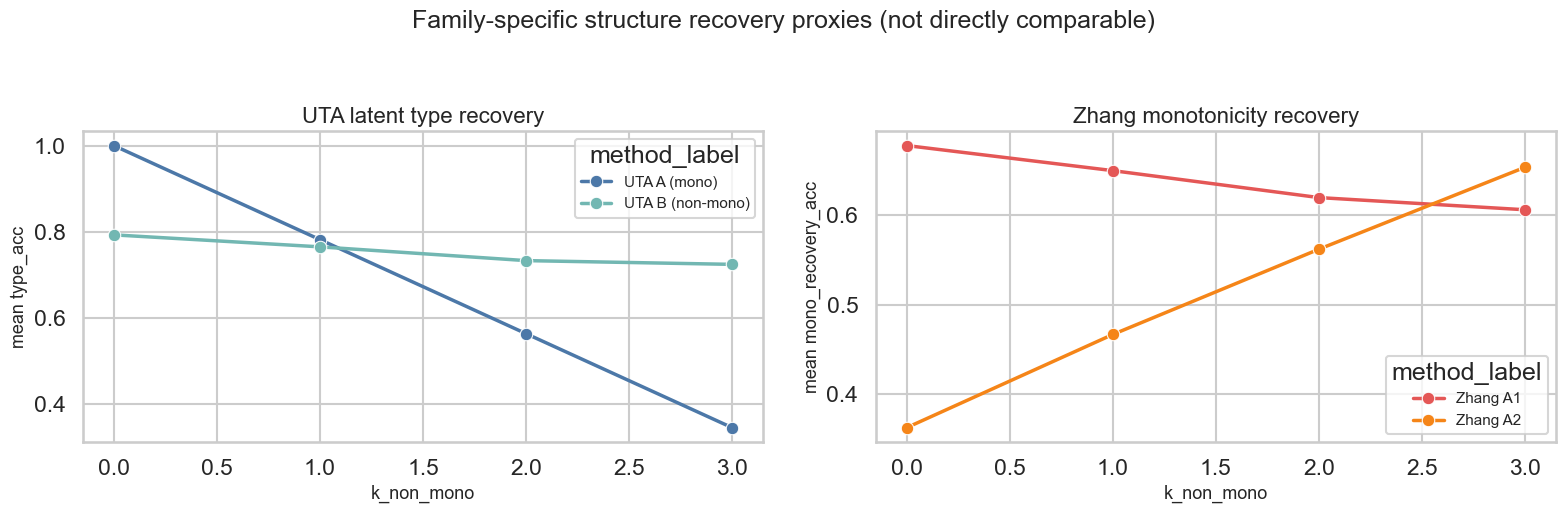

In [26]:
uta_struct = uta.groupby(["k_non_mono", "method_label"])["type_acc"].mean().reset_index()
zh_struct = zh.groupby(["k_non_mono", "method_label"])["mono_recovery_acc"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

sns.lineplot(
    data=uta_struct,
    x="k_non_mono",
    y="type_acc",
    hue="method_label",
    hue_order=["UTA A (mono)", "UTA B (non-mono)"],
    palette=METHOD_PALETTE,
    marker="o",
    linewidth=2.5,
    ax=axes[0],
)
axes[0].set_title("UTA latent type recovery")
axes[0].set_xlabel("k_non_mono")
axes[0].set_ylabel("mean type_acc")

sns.lineplot(
    data=zh_struct,
    x="k_non_mono",
    y="mono_recovery_acc",
    hue="method_label",
    hue_order=["Zhang A1", "Zhang A2"],
    palette=METHOD_PALETTE,
    marker="o",
    linewidth=2.5,
    ax=axes[1],
)
axes[1].set_title("Zhang monotonicity recovery")
axes[1].set_xlabel("k_non_mono")
axes[1].set_ylabel("mean mono_recovery_acc")

plt.suptitle("Family-specific structure recovery proxies (not directly comparable)", y=1.04, fontsize=18)
plt.tight_layout()
maybe_savefig("06_structure_proxies.png")
plt.show()
